### Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from sklearn.neighbors import KNeighborsClassifier
import pvlib
from scipy.stats import ks_2samp
from sklearn.metrics import root_mean_squared_error
from kgcpy import *
from scipy.optimize import minimize
from timezonefinder import TimezoneFinder
from datetime import datetime
import pytz

### Defining the variables for the script inputs

In [2]:
noOfdays = 365
mins_per_day = 1440
hrs_per_day = 24
noOfHrs = hrs_per_day * noOfdays
noOfMins = mins_per_day * noOfdays

lat_deg = 36.0581
lon_deg = 140.1258
altitude = 25

# Initialize the TimezoneFinder
tf = TimezoneFinder()
latitude = lat_deg
longitude = lon_deg
# Get the timezone name
timezone_str = tf.timezone_at(lng=longitude, lat=latitude)
tz = timezone_str
# tz='Etc/GMT'

start = pd.Timestamp("2013-01-01 00:00:00", tz=tz)  # Start time
end = pd.Timestamp("2013-12-31 23:59:00", tz=tz)  # End time

In [3]:
tz

'Asia/Tokyo'

In [4]:
lat = lat_deg
lon = lon_deg
# Look up the Köppen-Geiger climate zone
kg_zone = lookupCZ(lat, lon)
# kg_zone

# Determine the result based on the first letter of kg_zone
first_letter = kg_zone

if first_letter == "Af":
    result = "Aw"
elif first_letter == "Am":
    result = "Aw"
elif first_letter == "As":
    result = "Aw"
elif first_letter == "Aw":
    result = "Aw"
elif first_letter == "BSh":
    result = "BSh"
elif first_letter == "BSk":
    result = "BSk"
elif first_letter == "BWh":
    result = "BWh"
elif first_letter == "BWk":
    result = "BWh"
elif first_letter == "Cfa":
    result = "Cfa"
elif first_letter == "Cfb":
    result = "Cfb"
elif first_letter == "Cfc":
    result = "Cfb"
elif first_letter == "Csa":
    result = "Csa"
elif first_letter == "Csb":
    result = "Csb"
elif first_letter == "Csc":
    result = "Csb"
elif first_letter in ("Cwa", "Cwb", "Cwc"):
    result = "Csb"
elif first_letter in (
    "Dfa",
    "Dfb",
    "Dfc",
    "Dfd",
    "Dsa",
    "Dsb",
    "Dsc",
    "Dsd",
    "Dwa",
    "Dwb",
    "Dwc",
    "Dwd",
    "EF",
    "ET",
):
    result = "Others"
else:
    result = "Others"  # Fallback in case of an unexpected value
print("Climate zone:", kg_zone)
result

Climate zone: Cfa


'Cfa'

### Importing measured hourly DNI and GHI

In [5]:
hourly_irrad_m = np.genfromtxt(
    "TAT.csv", delimiter=","
)  # importing hourly timeseries- should be 8760 items for one year, the columns are day (1-365), hour (1-24), GHI (W/m2), DNI (W/m2)
hourly_irrad_m

array([[  1.,   1.,   0.],
       [  1.,   2.,   0.],
       [  1.,   3.,   0.],
       ...,
       [365.,  22.,   0.],
       [365.,  23.,   0.],
       [365.,  24.,   0.]])

### Importing training data for specified climate zones at hourly and minute resolution

In [6]:
hourly_database_ghi = np.genfromtxt(
    f"C:/Users/o.omoyele/Desktop/Australia/ND_Model_Mean_QC/{result}/input_knn.csv",
    delimiter=",",
)
# this gets the climate data for KG climate classification zones --currently its about 14 years of data
minutal_database_ghi = np.genfromtxt(
    f"C:/Users/o.omoyele/Desktop/Australia/ND_Model_Mean_QC/{result}/minutal_new.csv",
    delimiter=",",
)
# this is the same data at a minutal resolution -- has dimensionless/clearsky GHI and DNI in there. Number of steps are 1000 which need to be confirmed. -- need to be confirmed from prof. if it is dimensionless GHI & DNI or clearsky GHI & DNI

### Training the data

In [7]:
neigh_ghi = KNeighborsClassifier(n_neighbors=1)
neigh_ghi.fit(
    hourly_database_ghi[:, [1, 2, 3, 4, 5]], hourly_database_ghi[:, 0]
)  # training the KNN classifier using the inputs as columns 1, 2, 3, and 4 and the labels from column 0 as the target variable for classification

KNeighborsClassifier(n_neighbors=1)

### Importing clear sky DNI and GHI using McClear at hourly and minutal resolution -- PVLib API call for CAMS McClear

In [8]:
# for DNI
##hourly clear sky dni
hourly_cs, metadata = pvlib.iotools.get_cams(
    latitude=lat_deg,
    longitude=lon_deg,
    start=start,
    end=end,
    email="jo.omoyele@gmail.com",
    identifier="mcclear",
    altitude=altitude,
    time_step="1h",
    time_ref="TST",
    verbose=False,
    integrated=False,
    label=None,
    map_variables=True,
    server="api.soda-solardata.com",
    timeout=600,
)

hourly_irrad_cs_dni = hourly_cs[["dni_clear"]].reset_index(drop=True)
hourly_irrad_cs_dni = hourly_irrad_cs_dni.to_numpy().reshape(noOfHrs)
hourly_irrad_cs_ghi = hourly_cs[["ghi_extra"]].reset_index(drop=True)
hourly_irrad_cs_ghi = hourly_irrad_cs_ghi.to_numpy().reshape(noOfHrs)

# minutal clear sky dni
minutal_cs, metadata = pvlib.iotools.get_cams(
    latitude=lat_deg,
    longitude=lon_deg,
    start=start,
    end=end,
    email="jo.omoyele@gmail.com",
    identifier="mcclear",
    altitude=altitude,
    time_step="1min",
    time_ref="TST",
    verbose=False,
    integrated=False,
    label=None,
    map_variables=True,
    server="api.soda-solardata.com",
    timeout=600,
)

min_irrad_cs_dni = minutal_cs[["dni_clear"]].reset_index(drop=True)
min_irrad_cs_dni = min_irrad_cs_dni.to_numpy().reshape(noOfMins)
min_irrad_cs_ghi = minutal_cs[["ghi_extra"]].reset_index(drop=True)
min_irrad_cs_ghi = min_irrad_cs_ghi.to_numpy().reshape(noOfMins)

### Getting solar Altitude angle (alpha) and Hour angle (omega) in degrees as these will be needed to create masks --calling PVlib function

In [9]:
date_range = pd.date_range(start=start, end=end, freq="1h")

solar_position = pvlib.solarposition.get_solarposition(
    date_range, latitude=lat_deg, longitude=lon_deg, altitude=altitude, pressure=1013.25
)

alpha_deg = solar_position["elevation"].values
EOT = solar_position["equation_of_time"].values  # in minutes

omega_deg = pvlib.solarposition.hour_angle(
    date_range, longitude=lon_deg, equation_of_time=EOT
)

### Creating Masks to set negative altitude angles irradiation to 0 and to get a Before-Noon Mask for Morning Fraction Fm

In [10]:
# creating mask for when the altitude angle is less than 0 (or is negative)
neg_alpha_deg_mask = (
    alpha_deg <= 0
)  # boolean mask that keeps negative altitude angles (in degrees)

# creating a 2d (daily) array of the mask
neg_alpha_deg_mask_2d = np.copy(neg_alpha_deg_mask)
neg_alpha_deg_mask_2d.shape = (
    noOfdays,
    hrs_per_day,
)  # transformation of array to 2D from 1D

# for before-noon mask for morning fraction
before_noon_mask = (
    omega_deg < 0
)  # boolean mask for before-noon solar hour angles in radians

### Converting the measured and clear sky DNI to 2d (daily) for calculation of Clear Sky Index or dimensionless irradiance

In [11]:
hourly_irrad_cs_ghi_2d = np.copy(hourly_irrad_cs_ghi)
hourly_irrad_cs_ghi_2d.shape = (noOfdays, hrs_per_day)
hourly_irrad_cs_ghi_2d[neg_alpha_deg_mask_2d] = (
    0  # masked to 0 using negative altitude angles mask
)

hourly_irrad_m_ghi_2d = np.copy(hourly_irrad_m[:, 2])
hourly_irrad_m_ghi_2d.shape = (noOfdays, hrs_per_day)
hourly_irrad_m_ghi_2d[neg_alpha_deg_mask_2d] = (
    0  # masked to 0 using negative altitude angles mask
)

### Calculation of the daily Clear Sky Index or Dimensionless Irradiance or Direct Fraction Kb for DNI

In [12]:
# Kb = hourly_irrad_m_dni_2d.sum(1) / hourly_irrad_cs_dni_2d.sum(1) #calculation for the daily direct fraction index Kb by summing along axis 1 (columns) and then dividing the sums element wise
Kt = (
    hourly_irrad_m_ghi_2d.sum(1) / hourly_irrad_cs_ghi_2d.sum(1)
)  # calculation for the daily direct fraction index Kt by summing along axis 1 (columns) and then dividing the sums element wise

days = 365
# points_per_day = 1440  # since there are 1440 minutes in a day (525600 / 365)
day_points = 24

data_A = hourly_cs["ghi_extra"].values.reshape((days, day_points))
# data_A
data_B = hourly_irrad_m[:, 2].reshape((days, day_points))
# data_B

data_A1 = pd.DataFrame(data_A)
data_B1 = pd.DataFrame(data_B)

Kt_new = data_B1.mean(1) / data_A1.mean(1)

### Calculation of the Variability Index VI

In [13]:
days = 365
# points_per_day = 1440  # since there are 1440 minutes in a day (525600 / 365)
day_points = 24
# Convert series to dataframes and reshape

data_A = hourly_cs["ghi_extra"].values.reshape((days, day_points))
# data_A
data_B = hourly_irrad_m[:, 2].reshape((days, day_points))
# data_B

data_A1 = pd.DataFrame(data_A).transpose()
data_B1 = pd.DataFrame(data_B).transpose()
data_A1 = data_A1.values
data_B1 = data_B1.values

data_C1 = np.sort(data_B, axis=1)[:, ::-1]
data_C1 = pd.DataFrame(data_C1)
data_C1 = data_C1.transpose().values


# data_A1
a_values = np.zeros(data_A1.shape[1])
# Loop over each column
for i in range(data_A1.shape[1]):
    # Calculate daily differences for the current column
    daily_differences_a_values = np.diff(data_A1[:, i])

    # Compute the value of a for the current column
    a_values[i] = np.power(np.power(daily_differences_a_values, 2) + 1, 1 / 2).sum()
irradiance_cs = pd.DataFrame({"days": a_values})
# irradiance_cs

b_values = np.zeros(data_B1.shape[1])
# Loop over each column
for i in range(data_B1.shape[1]):
    # Calculate daily differences for the current column
    daily_differences_b_values = np.diff(data_B1[:, i])

    # Compute the value of a for the current column
    b_values[i] = np.power(np.power(daily_differences_b_values, 2) + 1, 1 / 2).sum()

irradiance = pd.DataFrame({"days": b_values})
# irradiance

c_values = np.zeros(data_C1.shape[1])
# Loop over each column
for i in range(data_C1.shape[1]):
    # Calculate daily differences for the current column
    daily_differences_c_values = np.diff(data_C1[:, i])

    # Compute the value of a for the current column
    c_values[i] = np.power(np.power(daily_differences_c_values, 2) + 1, 1 / 2).sum()

irradiance_norm = pd.DataFrame({"days": c_values})
# irradiance

VI1 = irradiance["days"] / irradiance_cs["days"]
NVI1 = irradiance["days"] / irradiance_norm["days"]

### Calculation of the Morning Fraction Fm

In [14]:
after_noon_mask = np.logical_not(
    before_noon_mask
)  # mask for afternoon - opposite of before noon mask
after_noon_mask_2d = np.copy(after_noon_mask)  # new copy for 2D transformation
after_noon_mask_2d.shape = (noOfdays, hrs_per_day)  # 2D transformation


hourly_irrad_m_after_noon_ghi_2d = np.copy(
    hourly_irrad_m_ghi_2d
)  # copy of measured irradiance array
hourly_irrad_m_after_noon_ghi_2d[after_noon_mask_2d] = (
    0  # setting afternoon values to 0 - this is done as morning fraction is the ratio of the sum of the irradiance in the first half with the whole day
)

Fm_ghi = hourly_irrad_m_after_noon_ghi_2d.sum(1) / hourly_irrad_m_ghi_2d.sum(
    1
)  # sum along the second axis and dividing element-wise for Fm
Fm_ghi = np.nan_to_num(Fm_ghi)  # if division leads to NaN, replace with 0

In [15]:
data = hourly_irrad_m[:, 2]

# Initialize a list to store normalized IC-CDF values for each day
normalized_ic_cdf_values = []

# Loop through each day and compute the normalized IC-CDF
for day in range(noOfdays):
    # Step 1: Extract hourly data for the current day
    daily_data = data[day * hrs_per_day : (day + 1) * hrs_per_day]

    # Step 2: Compute the time-differenced series (hourly changes)
    differenced_data = np.diff(daily_data)

    # Step 3: Sort the differenced data and compute the empirical CDF
    sorted_diff = np.sort(differenced_data)
    n = len(sorted_diff)
    cdf = np.arange(1, n + 1) / n

    # Step 4: Calculate the Complementary CDF (CCDF)
    ccdf = 1 - cdf

    # Step 5: Compute the IC-CDF using the trapezoidal rule
    ic_cdf = np.trapezoid(ccdf, sorted_diff)

    # Step 6: Normalize the IC-CDF by dividing by the range of the differenced data
    diff_range = sorted_diff.max() - sorted_diff.min()
    if diff_range != 0:  # Avoid division by zero
        normalized_ic_cdf = ic_cdf / diff_range
    else:
        normalized_ic_cdf = 0  # If range is zero, set normalized IC-CDF to 0

    # Store the normalized IC-CDF value
    normalized_ic_cdf_values.append(normalized_ic_cdf)


daily_means = []

for day in range(noOfdays):
    # Step 1: Extract hourly data for the current day
    daily_data = data[day * hrs_per_day : (day + 1) * hrs_per_day]

    # Step 2: Compute the mean of the daily data
    daily_mean = np.mean(daily_data)

    # Store the daily mean
    daily_means.append(daily_mean)

### Packaging the obtained daily indicators

In [16]:
calculated_indicators_ghi = np.zeros((days, 5))
calculated_indicators_ghi[:, 0] = Kt_new
calculated_indicators_ghi[:, 1] = VI1
calculated_indicators_ghi[:, 2] = Fm_ghi
calculated_indicators_ghi[:, 3] = NVI1
calculated_indicators_ghi[:, 4] = normalized_ic_cdf_values
# calculated_indicators_ghi[:,5] = daily_means

### Predicting Similar Days

In [17]:
similar_days_ghi = neigh_ghi.predict(
    calculated_indicators_ghi
)  # predicting the class labels for similar days from calculated indices (only Kb, and VI here for now)
similar_days_ghi.shape

(365,)

### Getting the altitude or elevation angles (alpha) in minute resolution - calling PVlib function

In [18]:
def get_etc_gmt_from_latlon(lat, lon):
    # Initialize TimezoneFinder
    tf = TimezoneFinder()

    # Get timezone name from coordinates
    timezone_str = tf.timezone_at(lat=lat, lng=lon)

    if timezone_str is None:
        return None  # Return None if no timezone is found

    # Get UTC offset from the timezone
    tz = pytz.timezone(timezone_str)
    utc_offset = tz.utcoffset(datetime.now()).total_seconds() / 3600

    # Convert the UTC offset to Etc/GMT-x format
    if utc_offset == 0:
        etc_gmt = "Etc/GMT"
    else:
        etc_gmt = f"Etc/GMT{'+' if utc_offset < 0 else '-'}{abs(int(utc_offset))}"

    return etc_gmt


etc_gmt = get_etc_gmt_from_latlon(lat, lon)
print(etc_gmt)

start = pd.Timestamp("2013-01-01 00:00:00", tz=tz)  # Start time
end = pd.Timestamp("2013-12-31 23:59:00", tz=tz)  # End time

date_range = pd.date_range(start=start, end=end, freq="1min")
# date_range_utc = date_range.tz_convert('UTC')
solar_position = pvlib.solarposition.get_solarposition(
    date_range, latitude=lat_deg, longitude=lon_deg, altitude=altitude, pressure=1013.25
)

alpha_deg_min = solar_position["elevation"].values

Etc/GMT-9


### Getting the needed mask - positive alpha in degrees in 2D

In [19]:
pos_alpha_deg_mask_min = alpha_deg_min > 0  # masking for positive altitude angles
pos_alpha_deg_min = np.maximum(
    alpha_deg_min, 0
)  # keeping maxima of either altitude angles or 0 to exclude negatives

pos_alpha_deg_mask_min_2d = np.copy(pos_alpha_deg_mask_min)
pos_alpha_deg_mask_min_2d.shape = (noOfdays, mins_per_day)  # reshaping for minutes

### Upscaling now to minutal resolution for Kb and Kt

In [20]:
min_syn_kb = []
min_syn_kt = []
syn_day = np.zeros(
    (24 * 60, 2)
)  # new array with daily data at minutal resolution represented by zeros

for i in range(0, noOfdays):  # iterating for the year across each day
    ups_day_ghi = minutal_database_ghi[
        np.where(minutal_database_ghi[:, 0] == similar_days_ghi[i])
    ]  # gets the data from minutal dataset for each similar day -- in other words, get 1000 rows for each similar day
    indices = np.around(
        1000
        * np.arange(1, np.sum(pos_alpha_deg_mask_min_2d[i]) + 1)
        / np.sum(pos_alpha_deg_mask_min_2d[i])
    )  # here we generate indices to later sample the ups_day data -- the indices generated are generated as a fraction of the total time the sum is up and is therefore then multiplied by 1000 to scale it up
    syn_day[pos_alpha_deg_mask_min_2d[i]] = ups_day_ghi[indices.astype(int) - 1][
        :, 1:3
    ]  # fills the synthetic day data with the sampled values from the ups_day for each of the created indices (as integer) in each similar day -- so for each similar day, only those rows of the 1000 rows are picked for Kb and Kt which are indexed using indices
    min_syn_kt = np.append(
        min_syn_kt, syn_day[:, 1]
    )  # appends the synthetic solar irradiance data for the day to the min_syn_kt array

# print(ups_day_dni.shape)
print(ups_day_ghi.shape)

(1000, 2)


### Producing DNI and GHI now from synthetic minutal data

In [21]:
hourly_irrad_m_new = pd.DataFrame(data_B).sum(1)
syn_min_ghi_test = (min_syn_kt * min_irrad_cs_ghi).reshape(days, mins_per_day)
# syn_min_ghi_test = pd.DataFrame(syn_min_ghi_test)
syn_min_ghi_test = pd.DataFrame(syn_min_ghi_test).sum(1) / 60


# Function to minimize for each day
def objective(k, i):
    percentage_change = (
        hourly_irrad_m_new[i] - (k * syn_min_ghi_test[i])
    ) / hourly_irrad_m_new[i]
    return np.abs(percentage_change)


# Array to store optimal k values
optimal_k = np.zeros(days)

# Optimize k for each day
for i in range(days):
    result = minimize(objective, x0=0, args=(i,), bounds=[(0, 10)])
    optimal_k[i] = result.x[0]

# print("Optimal k values for each day:", optimal_k)


A = (min_syn_kt * min_irrad_cs_ghi).reshape(days, mins_per_day)
# A = pd.DataFrame(A)
B = A * optimal_k[:, np.newaxis]
B = pd.DataFrame(B)

df = pd.melt(B.transpose())

df = df.rename(columns={"value": "ghi"})
df.describe()

,variable,ghi
count,525600.000000,525600.000000
mean,182.000000,171.875610
std,105.366129,264.694383
min,0.000000,0.000000
25%,91.000000,0.000000
50%,182.000000,0.000000
75%,273.000000,269.453047
max,364.000000,1515.514023


### Exporting the synthetic minutal timeseries

### Plotting the GHI

### Plotting the synthetic and measured minutal timeseries to compare

In [24]:
data = pd.read_csv(
    r"C:\Users\o.omoyele\Desktop\Australia\ND_Model_Mean_QC\Validation_new_new\BSRN\TAT\df_TAT.csv",
    low_memory=False,
)

In [25]:
data.describe()

,ghi
count,525600.000000
mean,171.875611
std,263.167525
min,0.000000
25%,0.000000
50%,4.000000
75%,279.000000
max,1320.000000


### Validation - Performing KS Integral Test

In [26]:
# for DNI
# Perform the KSI test between the measured and synthetic distribution
statistic, p_value = ks_2samp(data["ghi"], df["ghi"])

# Output the results
print(
    "###################################################################################################"
)
print("Synthetic GHI")
print(
    "###################################################################################################"
)
print("Kolmogorov-Smirnov Test Results:")
print("Statistic:", statistic)
print("p-value:", p_value)

# Interpret the results
alpha = 0.05  # Significance level
if p_value > alpha:
    print(
        "The null hypothesis cannot be rejected. The samples may be drawn from the same distribution."
    )
else:
    print(
        "The null hypothesis is rejected. The samples are likely drawn from different distributions."
    )

# for KSI in %

vc = 1.63 / (len(data) ** (1 / 2))
a_critical = vc * (data["ghi"].max() - data["ghi"].min())
ksi_percentage = statistic / a_critical * 100

print("KSI as percentage is", round(ksi_percentage, 2), "%")

###################################################################################################
Synthetic GHI
###################################################################################################
Kolmogorov-Smirnov Test Results:
Statistic: 0.03419330289193301
p-value: 2.1799013561691897e-267
The null hypothesis is rejected. The samples are likely drawn from different distributions.
KSI as percentage is 1.15 %


### Getting RMSE and NRMSE

In [27]:
# for dni
# for synthetic dni

rms = root_mean_squared_error(data["ghi"], df["ghi"])
nrmse = round(rms / (data["ghi"].max() - data["ghi"].min()) * 100, 2)
print("###############################################################################")
print("Synthetic GHI")
print("###############################################################################")
print("RMSE is:", round(rms, 2))
print("NRMSE is:", nrmse, "%")

###############################################################################
Synthetic GHI
###############################################################################
RMSE is: 122.99
NRMSE is: 9.32 %


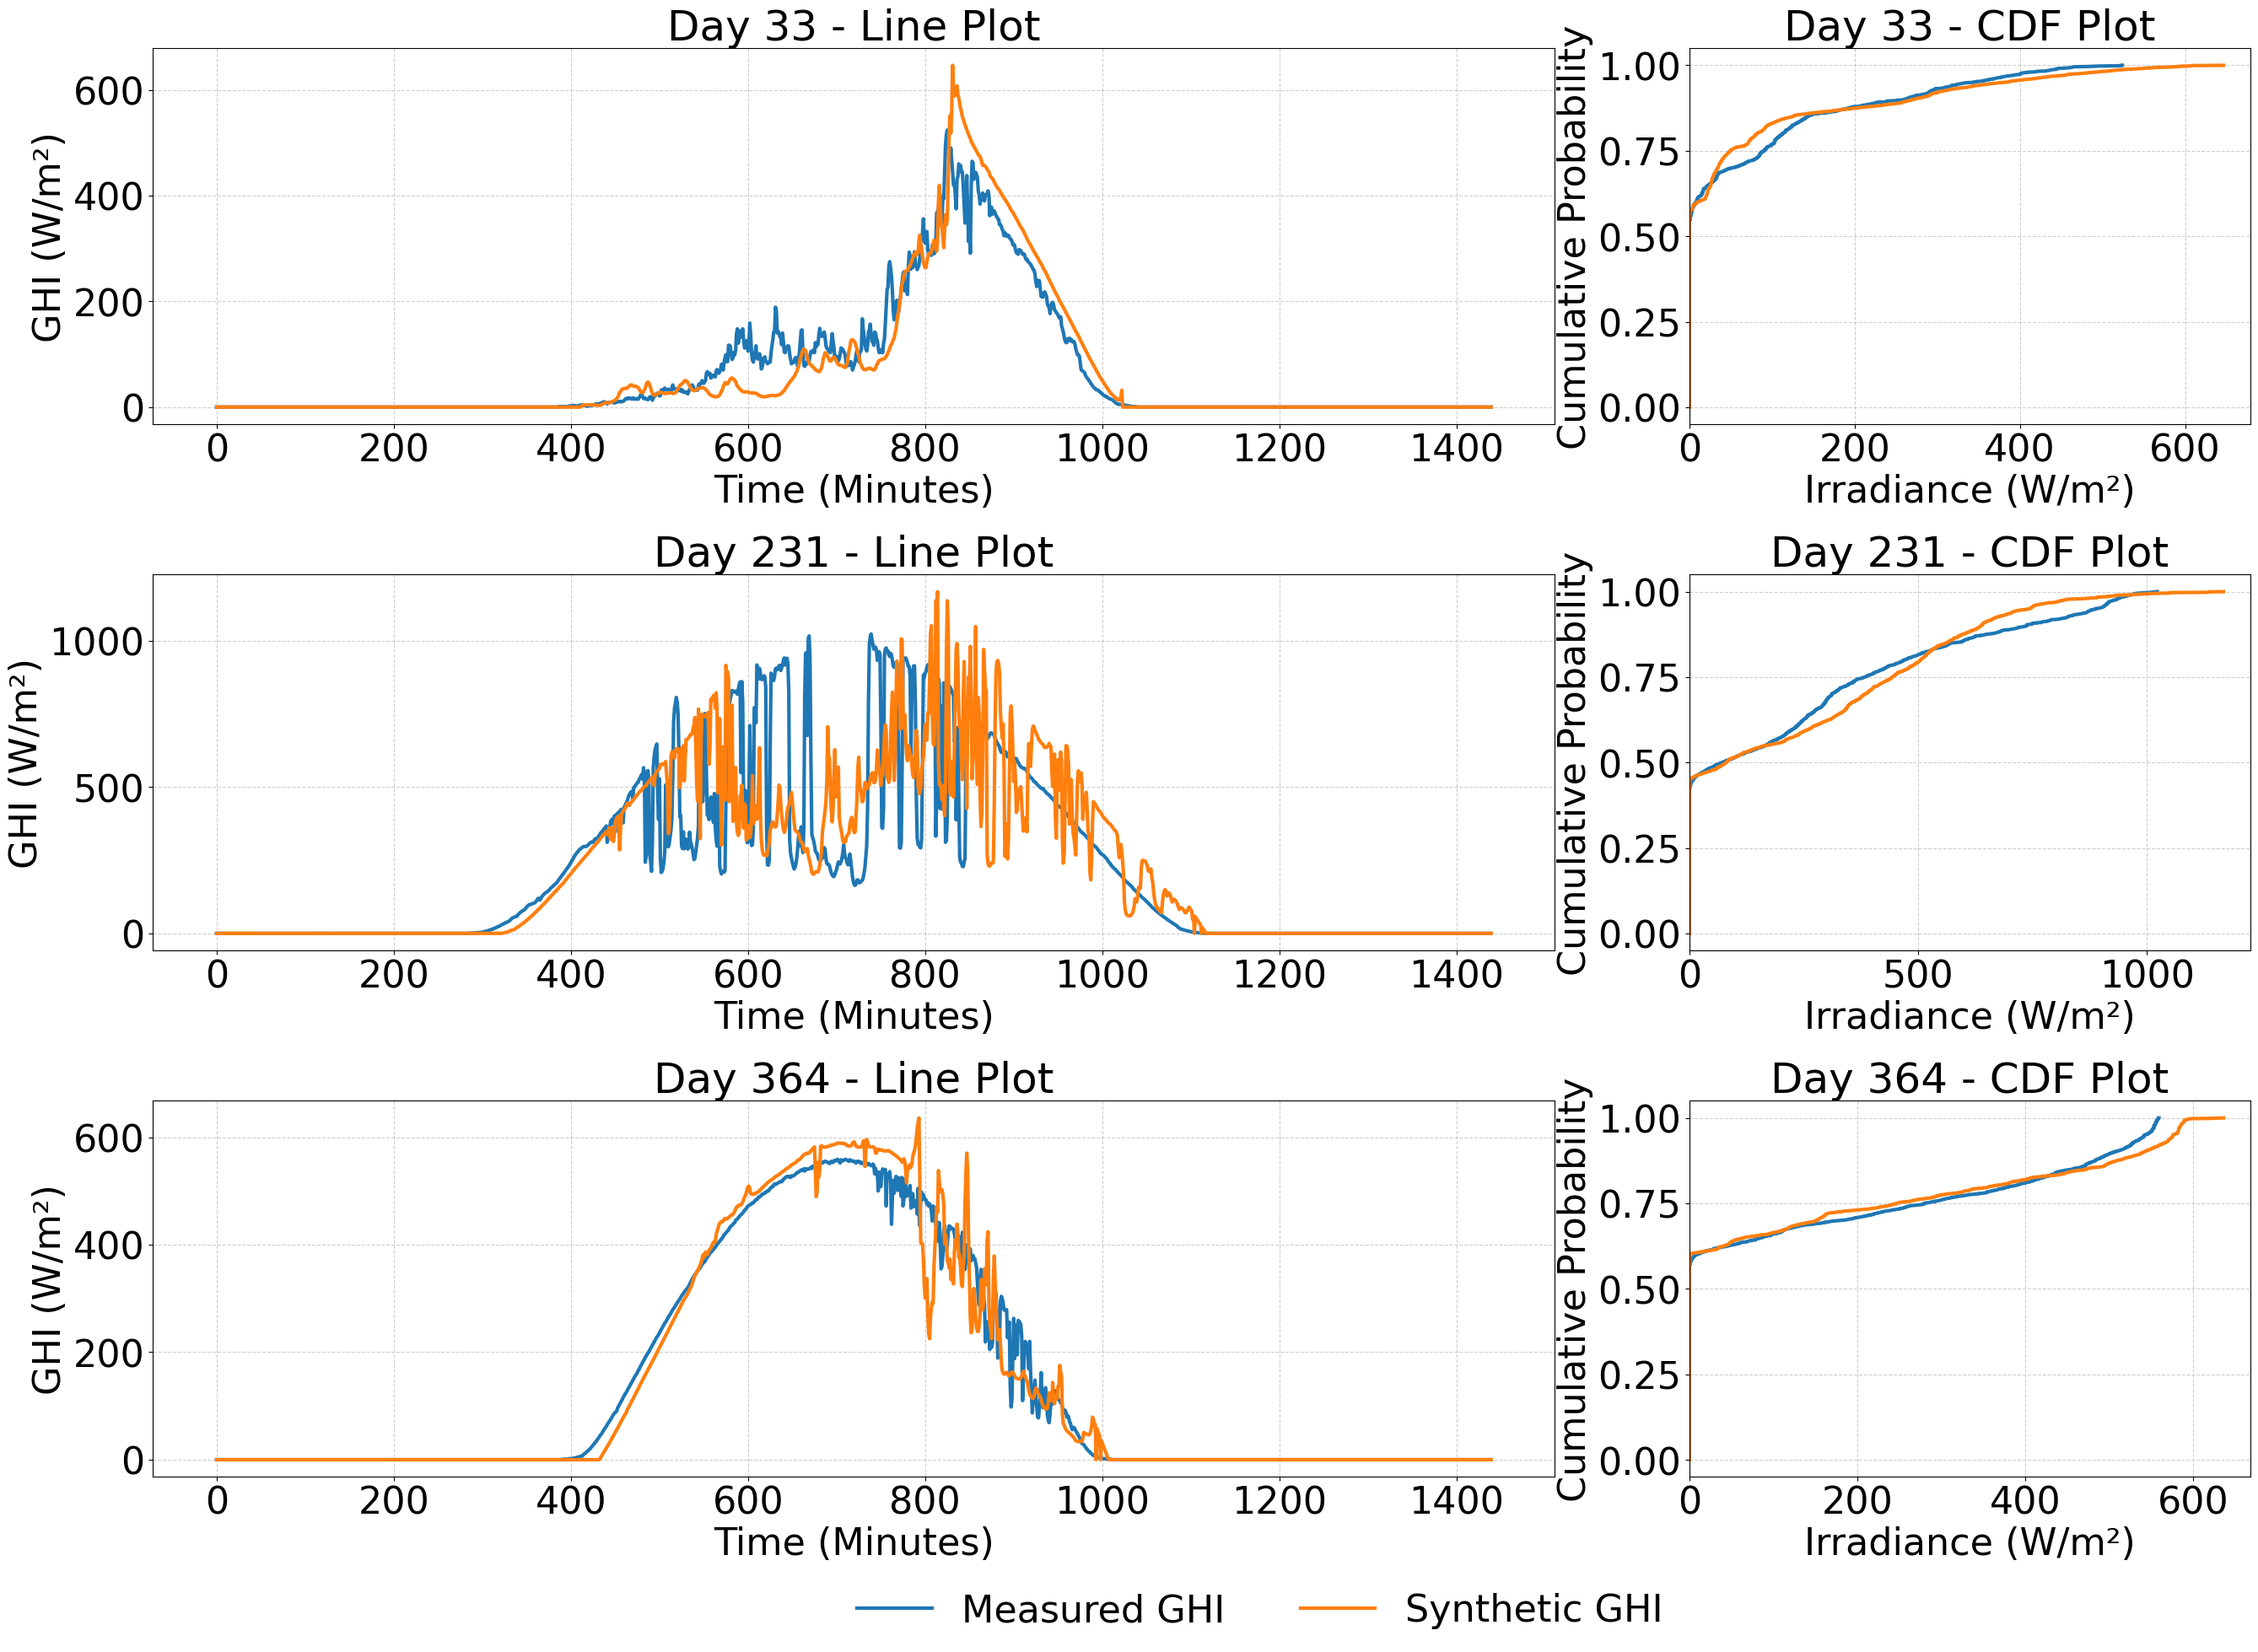

In [49]:
# Extract the GHI columns
ghi_measured = data["ghi"].values
ghi_synthetic = df["ghi"].values

# Reshape the data into 365 days, each with 1440 minutes
ghi_measured_reshaped = ghi_measured.reshape(noOfdays, 1440)
ghi_synthetic_reshaped = ghi_synthetic.reshape(noOfdays, 1440)

# Choose three arbitrary days to plot (e.g., day 50, day 100, day 150)
# days_to_plot = [3, 206, 364]
days_to_plot = [32, 230, 363]

fontsize = 36
fontsize1 = 32
fontsize2 = 32
linewidth = 3


# Calculate the CDF for the GHI data
def calculate_cdf(data):
    sorted_data = np.sort(data)
    cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    return sorted_data, cdf


# Create the figure and grid layout
fig = plt.figure(figsize=(35, 22))
gs = GridSpec(len(days_to_plot), 3, width_ratios=[2.5, 1, 0.1], hspace=0.4)

for i, day in enumerate(days_to_plot):
    # Line plot (GHI vs Time)
    ax_line = fig.add_subplot(gs[i, 0])
    ax_line.plot(
        ghi_measured_reshaped[day],
        label="Measured GHI",
        linestyle="-",
        linewidth=linewidth,
    )
    ax_line.plot(
        ghi_synthetic_reshaped[day],
        label="Synthetic GHI",
        linestyle="-",
        linewidth=linewidth,
    )
    ax_line.set_title(f"Day {day + 1} - Line Plot", fontsize=fontsize)
    ax_line.set_ylabel("GHI (W/m²)", fontsize=fontsize2)
    ax_line.set_xlabel("Time (Minutes)", fontsize=fontsize2)
    ax_line.tick_params(axis="both", which="major", labelsize=fontsize1)
    ax_line.grid(True, linestyle="--", alpha=0.6)
    # ax_line.legend(fontsize=fontsize1)

    # CDF plot (GHI vs Cumulative Probability)
    ax_cdf = fig.add_subplot(gs[i, 1])
    measured_sorted, measured_cdf = calculate_cdf(ghi_measured_reshaped[day])
    synthetic_sorted, synthetic_cdf = calculate_cdf(ghi_synthetic_reshaped[day])
    ax_cdf.plot(
        measured_sorted,
        measured_cdf,
        label="Measured GHI",
        linestyle="-",
        linewidth=linewidth,
    )
    ax_cdf.plot(
        synthetic_sorted,
        synthetic_cdf,
        label="Synthetic GHI",
        linestyle="-",
        linewidth=linewidth,
    )
    ax_cdf.set_title(f"Day {day + 1} - CDF Plot", fontsize=fontsize)
    ax_cdf.set_ylabel("Cumulative Probability", fontsize=fontsize2)
    ax_cdf.set_xlabel("Irradiance (W/m²)", fontsize=fontsize2)
    ax_cdf.tick_params(axis="both", which="major", labelsize=fontsize1)
    ax_cdf.grid(True, linestyle="--", alpha=0.6)
    ax_cdf.set_xlim(0, None)  # Start x-axis from zero


# Add a single legend below the entire figure
fig.legend(
    ["Measured GHI", "Synthetic GHI"],
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=2,
    fontsize=fontsize1,
    frameon=False,
)
plt.show()
# plt.savefig('ghi.png', bbox_inches='tight')

In [30]:
df["GHI"] = data["ghi"]

In [31]:
date_range = pd.date_range(start="01-01-2013 00:00", end="31-12-2013 23:59", freq="min")
df["date"] = pd.DataFrame(date_range)

In [32]:
df.set_index("date", inplace=True)
df

,variable,ghi,GHI
date,,,
2013-01-01 00:00:00,0,0.0,0
2013-01-01 00:01:00,0,0.0,0
2013-01-01 00:02:00,0,0.0,0
2013-01-01 00:03:00,0,0.0,0
2013-01-01 00:04:00,0,0.0,0
...,...,...,...
2013-12-31 23:55:00,364,0.0,0
2013-12-31 23:56:00,364,0.0,0
2013-12-31 23:57:00,364,0.0,0


In [33]:
df_hourly = df.resample("h").mean()

In [34]:
# for DNI
# Perform the KSI test between the measured and synthetic distribution
statistic, p_value = ks_2samp(df_hourly["GHI"], df_hourly["ghi"])

# Output the results
print(
    "###################################################################################################"
)
print("Synthetic GHI")
print(
    "###################################################################################################"
)
print("Kolmogorov-Smirnov Test Results:")
print("Statistic:", statistic)
print("p-value:", p_value)

# Interpret the results
alpha = 0.05  # Significance level
if p_value > alpha:
    print(
        "The null hypothesis cannot be rejected. The samples may be drawn from the same distribution."
    )
else:
    print(
        "The null hypothesis is rejected. The samples are likely drawn from different distributions."
    )

# for KSI in %

vc = 1.63 / (len(df_hourly) ** (1 / 2))
a_critical = vc * (df_hourly["GHI"].max() - df_hourly["GHI"].min())
ksi_percentage = statistic / a_critical * 100

print("KSI as percentage is", round(ksi_percentage, 2), "%")

###################################################################################################
Synthetic GHI
###################################################################################################
Kolmogorov-Smirnov Test Results:
Statistic: 0.039155251141552515
p-value: 2.9321615697793392e-06
The null hypothesis is rejected. The samples are likely drawn from different distributions.
KSI as percentage is 0.21 %


In [35]:
# for dni
# for synthetic dni

rms = root_mean_squared_error(df_hourly["GHI"], df_hourly["ghi"])
nrmse = round(rms / (df_hourly["GHI"].max() - df_hourly["GHI"].min()) * 100, 2)
print("###############################################################################")
print("Synthetic GHI")
print("###############################################################################")
print("RMSE is:", round(rms, 2))
print("NRMSE is:", nrmse, "%")

###############################################################################
Synthetic GHI
###############################################################################
RMSE is: 76.54
NRMSE is: 7.09 %


In [36]:
# Define a function to calculate NRMSE using range for each day
def calculate_nrmse(group):
    ghi = group["ghi"]
    GHI = group["GHI"]
    rmse = np.sqrt(np.mean((GHI - ghi) ** 2))
    ghi_range = GHI.max() - GHI.min()
    nrmse = rmse / ghi_range if ghi_range != 0 else np.nan  # Avoid division by zero
    return nrmse


# Group the data by day and calculate the daily NRMSE
daily_nrmse = df_hourly.groupby(df_hourly.index.date).apply(calculate_nrmse)

# Convert the result to a DataFrame for easy viewing
daily_nrmse_df = daily_nrmse.reset_index(name="NRMSE")
daily_nrmse_df.columns = ["Date", "NRMSE"]

# Display the results
print(daily_nrmse_df)

           Date     NRMSE
0    2013-01-01  0.059652
1    2013-01-02  0.049015
2    2013-01-03  0.074256
3    2013-01-04  0.032773
4    2013-01-05  0.152521
..          ...       ...
360  2013-12-27  0.176713
361  2013-12-28  0.032039
362  2013-12-29  0.032747
363  2013-12-30  0.028608
364  2013-12-31  0.050062

[365 rows x 2 columns]


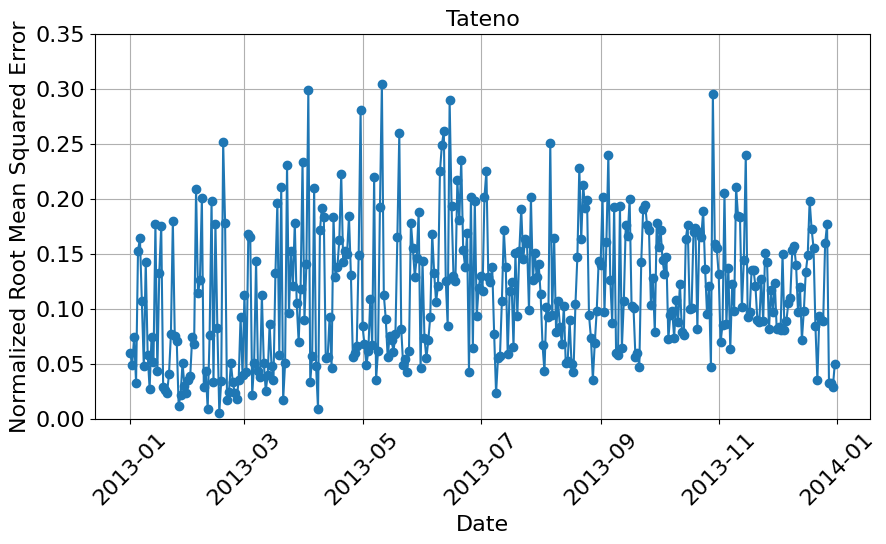

In [37]:
fontsize = 16

plt.figure(figsize=(10, 5))
plt.plot(daily_nrmse_df["Date"], daily_nrmse_df["NRMSE"], marker="o", linestyle="-")
plt.xlabel("Date", fontsize=fontsize)
plt.ylabel("Normalized Root Mean Squared Error", fontsize=fontsize)
plt.title("Tateno", fontsize=fontsize)
plt.xticks(rotation=45, fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.ylim(0, 0.35)
plt.grid()
plt.show()
# plt.savefig('daily_nrmse_df.png', dpi=300, bbox_inches='tight')

In [38]:
# Get the rows with the three smallest NRMSE values
three_smallest = daily_nrmse_df.nsmallest(3, "NRMSE")

# Get the rows with the three largest NRMSE values
three_largest = daily_nrmse_df.nlargest(3, "NRMSE")

# Display the results
print("Three Smallest NRMSE Values:")
print(three_smallest)

print("\nThree Largest NRMSE Values:")
print(three_largest)

Three Smallest NRMSE Values:
          Date     NRMSE
46  2013-02-16  0.005268
40  2013-02-10  0.008882
97  2013-04-08  0.008892

Three Largest NRMSE Values:
           Date     NRMSE
130  2013-05-11  0.304270
92   2013-04-03  0.298313
301  2013-10-29  0.295086


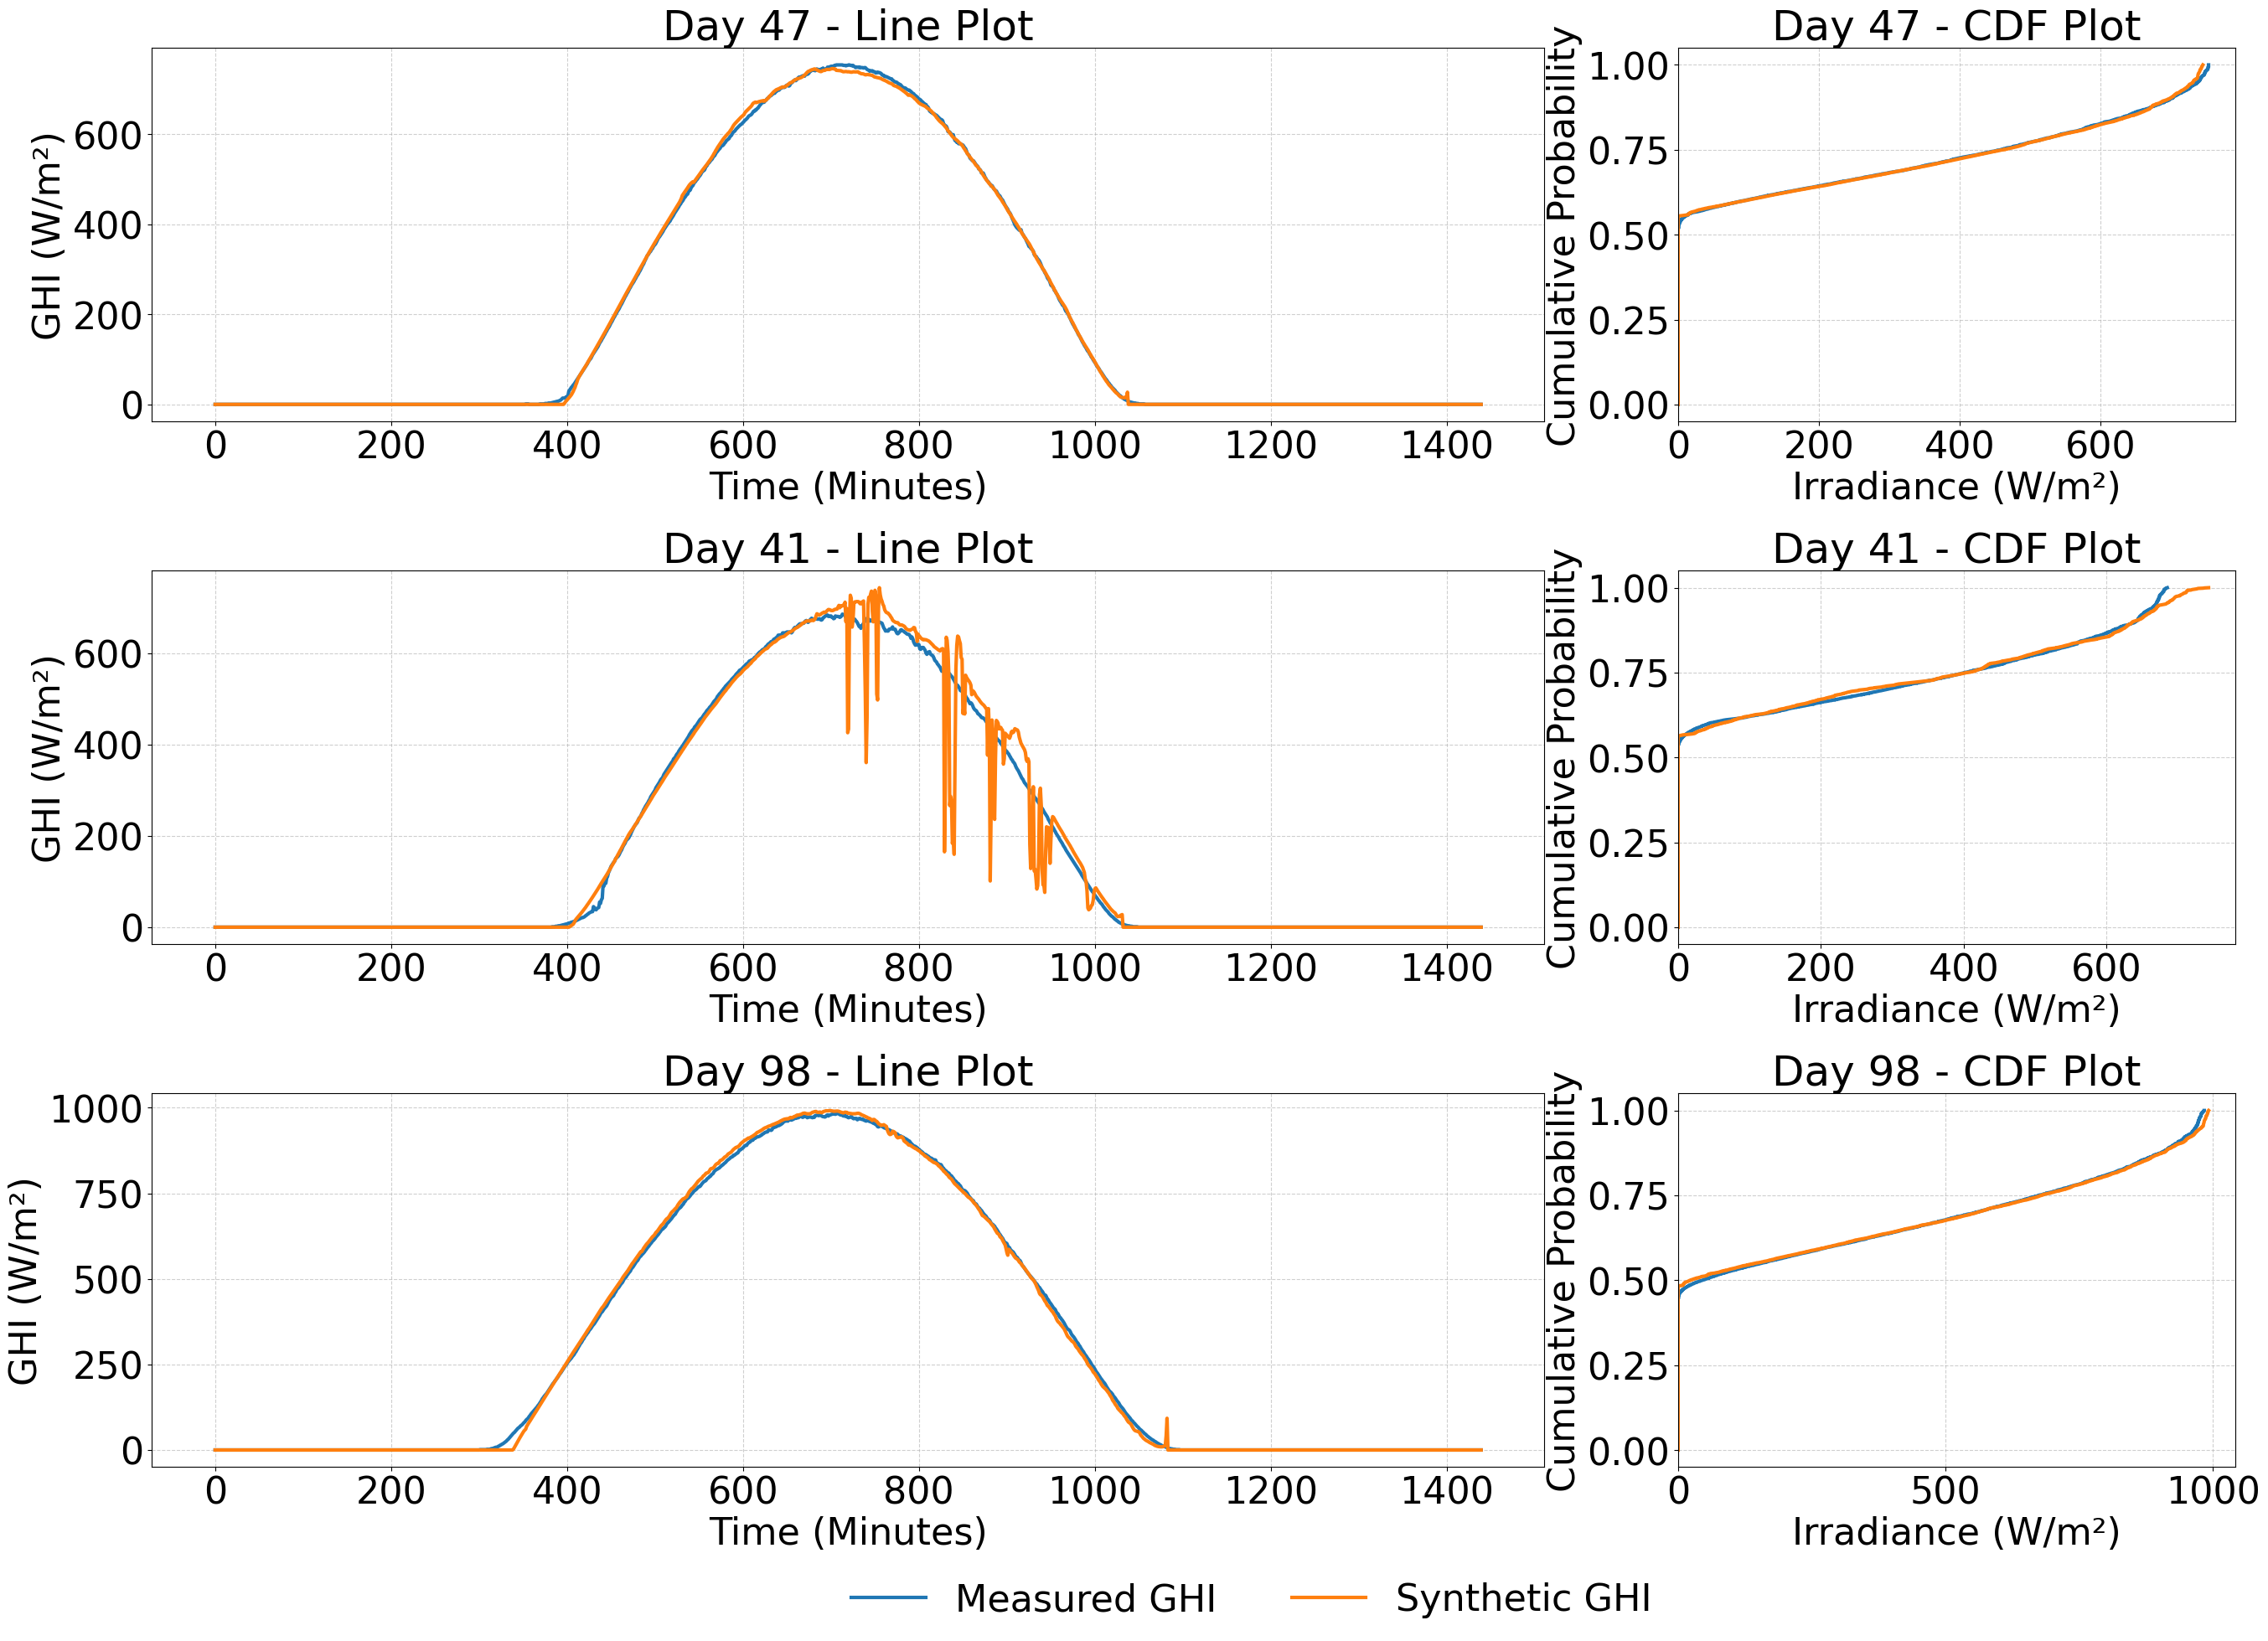

In [39]:
# Extract the GHI columns
ghi_measured = data["ghi"].values
ghi_synthetic = df["ghi"].values

# Reshape the data into 365 days, each with 1440 minutes
ghi_measured_reshaped = ghi_measured.reshape(noOfdays, 1440)
ghi_synthetic_reshaped = ghi_synthetic.reshape(noOfdays, 1440)

# Choose three arbitrary days to plot (e.g., day 50, day 100, day 150)
days_to_plot = [46, 40, 97]

fontsize = 36
fontsize1 = 32
fontsize2 = 32
linewidth = 3


# Calculate the CDF for the GHI data
def calculate_cdf(data):
    sorted_data = np.sort(data)
    cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    return sorted_data, cdf


# Create the figure and grid layout
fig = plt.figure(figsize=(35, 22))
gs = GridSpec(len(days_to_plot), 3, width_ratios=[2.5, 1, 0.1], hspace=0.4)

for i, day in enumerate(days_to_plot):
    # Line plot (GHI vs Time)
    ax_line = fig.add_subplot(gs[i, 0])
    ax_line.plot(
        ghi_measured_reshaped[day],
        label="Measured GHI",
        linestyle="-",
        linewidth=linewidth,
    )
    ax_line.plot(
        ghi_synthetic_reshaped[day],
        label="Synthetic GHI",
        linestyle="-",
        linewidth=linewidth,
    )
    ax_line.set_title(f"Day {day + 1} - Line Plot", fontsize=fontsize)
    ax_line.set_ylabel("GHI (W/m²)", fontsize=fontsize2)
    ax_line.set_xlabel("Time (Minutes)", fontsize=fontsize2)
    ax_line.tick_params(axis="both", which="major", labelsize=fontsize1)
    ax_line.grid(True, linestyle="--", alpha=0.6)
    # ax_line.legend(fontsize=fontsize1)

    # CDF plot (GHI vs Cumulative Probability)
    ax_cdf = fig.add_subplot(gs[i, 1])
    measured_sorted, measured_cdf = calculate_cdf(ghi_measured_reshaped[day])
    synthetic_sorted, synthetic_cdf = calculate_cdf(ghi_synthetic_reshaped[day])
    ax_cdf.plot(
        measured_sorted,
        measured_cdf,
        label="Measured GHI",
        linestyle="-",
        linewidth=linewidth,
    )
    ax_cdf.plot(
        synthetic_sorted,
        synthetic_cdf,
        label="Synthetic GHI",
        linestyle="-",
        linewidth=linewidth,
    )
    ax_cdf.set_title(f"Day {day + 1} - CDF Plot", fontsize=fontsize)
    ax_cdf.set_ylabel("Cumulative Probability", fontsize=fontsize2)
    ax_cdf.set_xlabel("Irradiance (W/m²)", fontsize=fontsize2)
    ax_cdf.tick_params(axis="both", which="major", labelsize=fontsize1)
    ax_cdf.grid(True, linestyle="--", alpha=0.6)
    ax_cdf.set_xlim(0, None)  # Start x-axis from zero


# Add a single legend below the entire figure
fig.legend(
    ["Measured GHI", "Synthetic GHI"],
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=2,
    fontsize=fontsize1,
    frameon=False,
)
plt.show()
# plt.savefig('ghi_min.png', bbox_inches='tight')

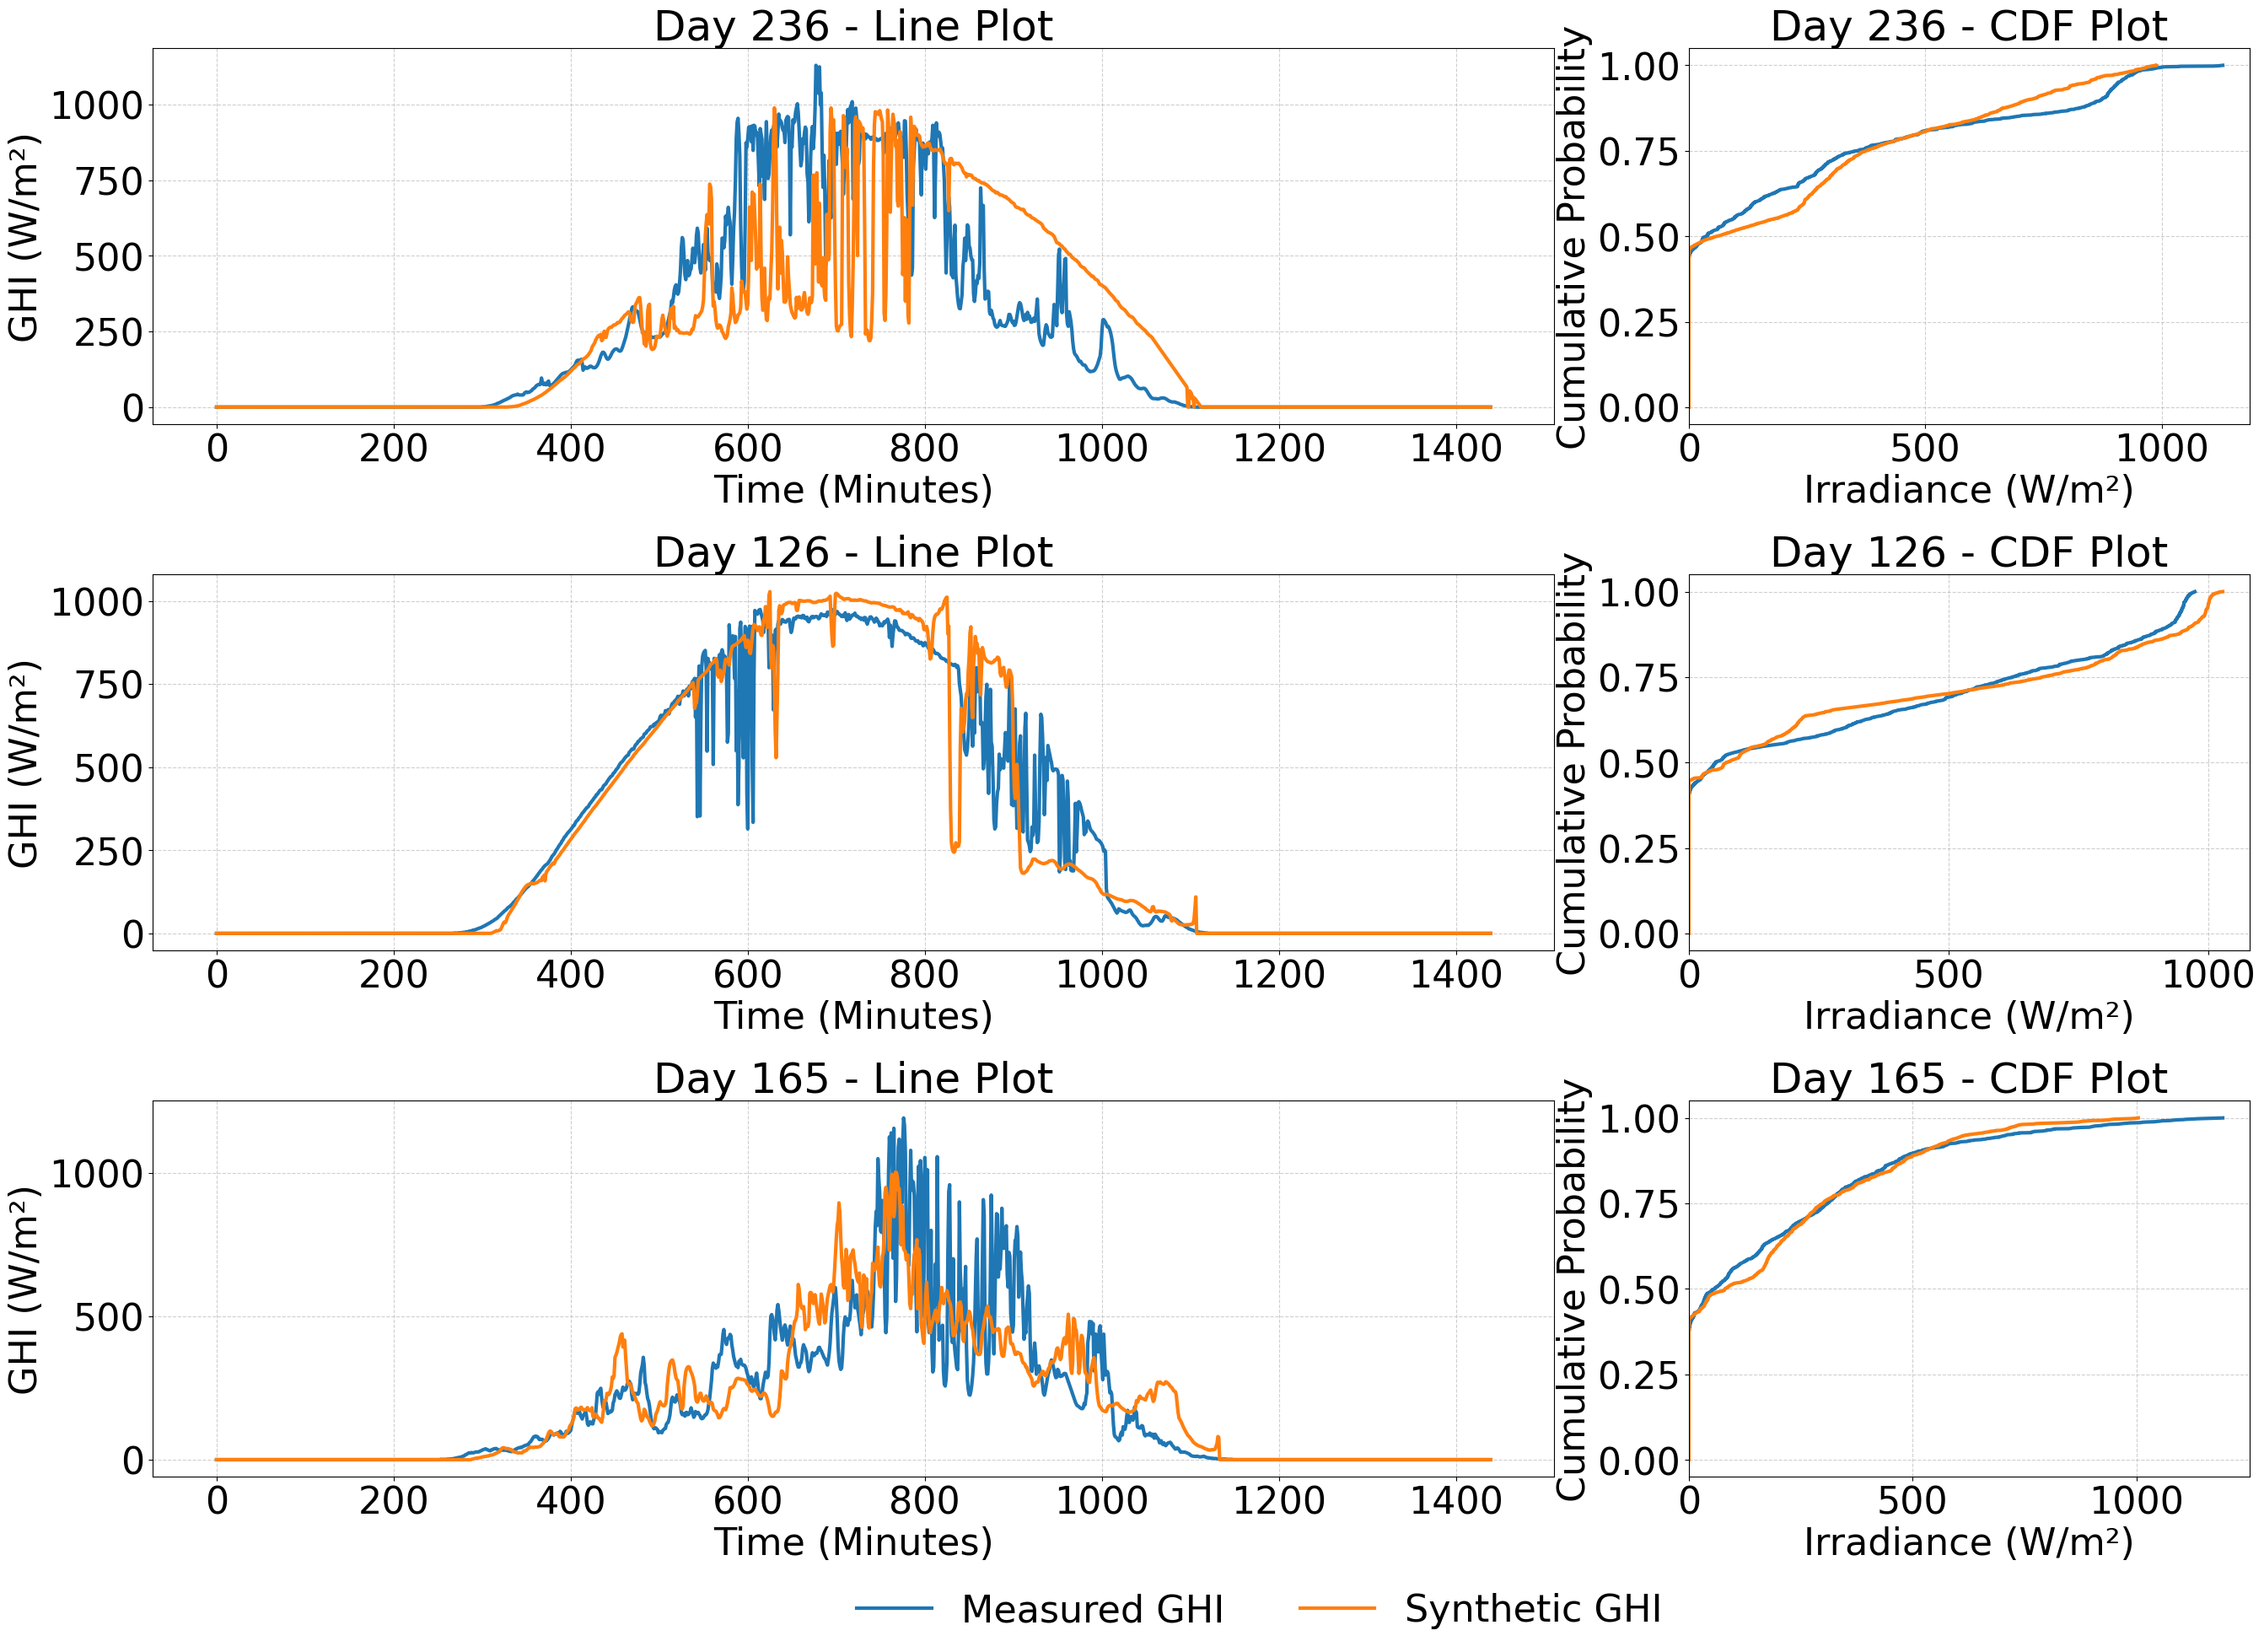

In [40]:
# Extract the GHI columns
ghi_measured = data["ghi"].values
ghi_synthetic = df["ghi"].values

# Reshape the data into 365 days, each with 1440 minutes
ghi_measured_reshaped = ghi_measured.reshape(noOfdays, 1440)
ghi_synthetic_reshaped = ghi_synthetic.reshape(noOfdays, 1440)

# Choose three arbitrary days to plot (e.g., day 50, day 100, day 150)
days_to_plot = [235, 125, 164]

fontsize = 36
fontsize1 = 32
fontsize2 = 32
linewidth = 3


# Calculate the CDF for the GHI data
def calculate_cdf(data):
    sorted_data = np.sort(data)
    cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    return sorted_data, cdf


# Create the figure and grid layout
fig = plt.figure(figsize=(35, 22))
gs = GridSpec(len(days_to_plot), 3, width_ratios=[2.5, 1, 0.1], hspace=0.4)

for i, day in enumerate(days_to_plot):
    # Line plot (GHI vs Time)
    ax_line = fig.add_subplot(gs[i, 0])
    ax_line.plot(
        ghi_measured_reshaped[day],
        label="Measured GHI",
        linestyle="-",
        linewidth=linewidth,
    )
    ax_line.plot(
        ghi_synthetic_reshaped[day],
        label="Synthetic GHI",
        linestyle="-",
        linewidth=linewidth,
    )
    ax_line.set_title(f"Day {day + 1} - Line Plot", fontsize=fontsize)
    ax_line.set_ylabel("GHI (W/m²)", fontsize=fontsize2)
    ax_line.set_xlabel("Time (Minutes)", fontsize=fontsize2)
    ax_line.tick_params(axis="both", which="major", labelsize=fontsize1)
    ax_line.grid(True, linestyle="--", alpha=0.6)
    # ax_line.legend(fontsize=fontsize1)

    # CDF plot (GHI vs Cumulative Probability)
    ax_cdf = fig.add_subplot(gs[i, 1])
    measured_sorted, measured_cdf = calculate_cdf(ghi_measured_reshaped[day])
    synthetic_sorted, synthetic_cdf = calculate_cdf(ghi_synthetic_reshaped[day])
    ax_cdf.plot(
        measured_sorted,
        measured_cdf,
        label="Measured GHI",
        linestyle="-",
        linewidth=linewidth,
    )
    ax_cdf.plot(
        synthetic_sorted,
        synthetic_cdf,
        label="Synthetic GHI",
        linestyle="-",
        linewidth=linewidth,
    )
    ax_cdf.set_title(f"Day {day + 1} - CDF Plot", fontsize=fontsize)
    ax_cdf.set_ylabel("Cumulative Probability", fontsize=fontsize2)
    ax_cdf.set_xlabel("Irradiance (W/m²)", fontsize=fontsize2)
    ax_cdf.tick_params(axis="both", which="major", labelsize=fontsize1)
    ax_cdf.grid(True, linestyle="--", alpha=0.6)
    ax_cdf.set_xlim(0, None)  # Start x-axis from zero


# Add a single legend below the entire figure
fig.legend(
    ["Measured GHI", "Synthetic GHI"],
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=2,
    fontsize=fontsize1,
    frameon=False,
)
plt.show()
# plt.savefig('ghi_max_old.png', bbox_inches='tight')

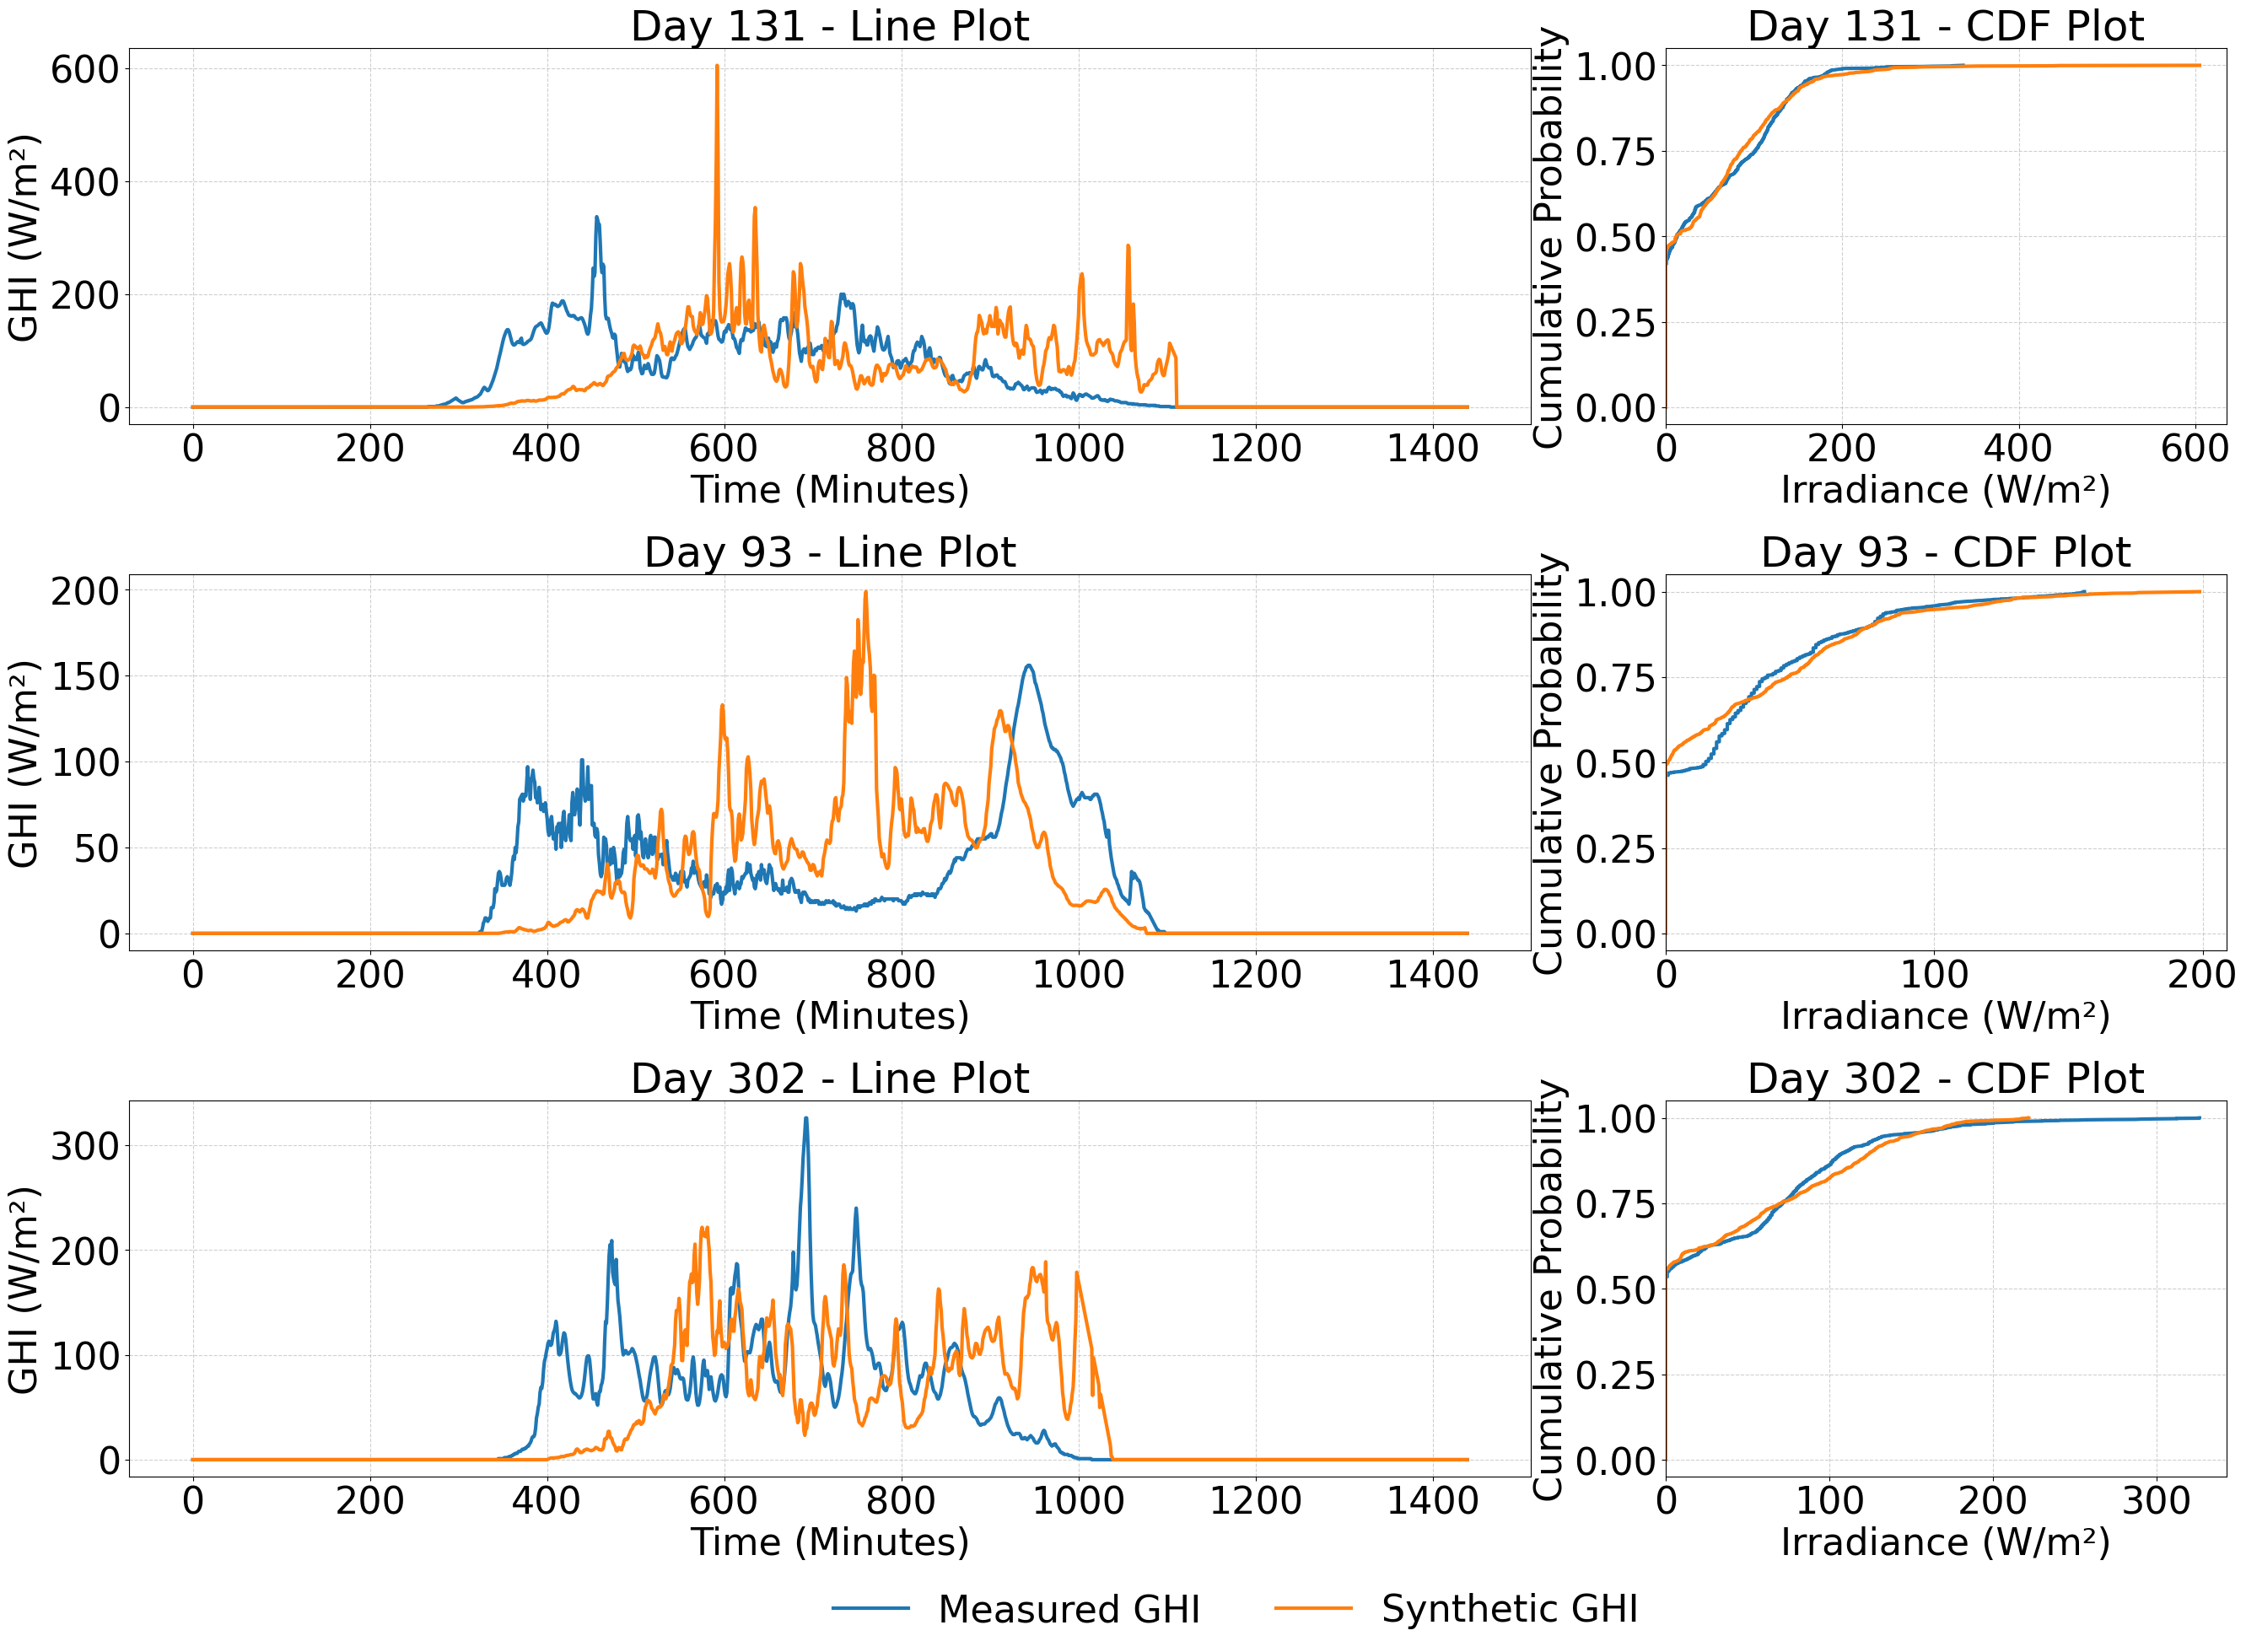

In [41]:
# Extract the GHI columns
ghi_measured = data["ghi"].values
ghi_synthetic = df["ghi"].values

# Reshape the data into 365 days, each with 1440 minutes
ghi_measured_reshaped = ghi_measured.reshape(noOfdays, 1440)
ghi_synthetic_reshaped = ghi_synthetic.reshape(noOfdays, 1440)

# Choose three arbitrary days to plot (e.g., day 50, day 100, day 150)
days_to_plot = [130, 92, 301]

fontsize = 36
fontsize1 = 32
fontsize2 = 32
linewidth = 3


# Calculate the CDF for the GHI data
def calculate_cdf(data):
    sorted_data = np.sort(data)
    cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    return sorted_data, cdf


# Create the figure and grid layout
fig = plt.figure(figsize=(35, 22))
gs = GridSpec(len(days_to_plot), 3, width_ratios=[2.5, 1, 0.1], hspace=0.4)

for i, day in enumerate(days_to_plot):
    # Line plot (GHI vs Time)
    ax_line = fig.add_subplot(gs[i, 0])
    ax_line.plot(
        ghi_measured_reshaped[day],
        label="Measured GHI",
        linestyle="-",
        linewidth=linewidth,
    )
    ax_line.plot(
        ghi_synthetic_reshaped[day],
        label="Synthetic GHI",
        linestyle="-",
        linewidth=linewidth,
    )
    ax_line.set_title(f"Day {day + 1} - Line Plot", fontsize=fontsize)
    ax_line.set_ylabel("GHI (W/m²)", fontsize=fontsize2)
    ax_line.set_xlabel("Time (Minutes)", fontsize=fontsize2)
    ax_line.tick_params(axis="both", which="major", labelsize=fontsize1)
    ax_line.grid(True, linestyle="--", alpha=0.6)
    # ax_line.legend(fontsize=fontsize1)

    # CDF plot (GHI vs Cumulative Probability)
    ax_cdf = fig.add_subplot(gs[i, 1])
    measured_sorted, measured_cdf = calculate_cdf(ghi_measured_reshaped[day])
    synthetic_sorted, synthetic_cdf = calculate_cdf(ghi_synthetic_reshaped[day])
    ax_cdf.plot(
        measured_sorted,
        measured_cdf,
        label="Measured GHI",
        linestyle="-",
        linewidth=linewidth,
    )
    ax_cdf.plot(
        synthetic_sorted,
        synthetic_cdf,
        label="Synthetic GHI",
        linestyle="-",
        linewidth=linewidth,
    )
    ax_cdf.set_title(f"Day {day + 1} - CDF Plot", fontsize=fontsize)
    ax_cdf.set_ylabel("Cumulative Probability", fontsize=fontsize2)
    ax_cdf.set_xlabel("Irradiance (W/m²)", fontsize=fontsize2)
    ax_cdf.tick_params(axis="both", which="major", labelsize=fontsize1)
    ax_cdf.grid(True, linestyle="--", alpha=0.6)
    ax_cdf.set_xlim(0, None)  # Start x-axis from zero


# Add a single legend below the entire figure
fig.legend(
    ["Measured GHI", "Synthetic GHI"],
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=2,
    fontsize=fontsize1,
    frameon=False,
)
plt.show()
# plt.savefig('ghi_max.png', bbox_inches='tight')